Authors: Hofmarcher

Date: 08-05-2026

---

This file is part of the "Deep Reinforcement Learning" lecture material. The following copyright statement applies to all code within this file.

Copyright statement:
This material, no matter whether in printed or electronic form, may be used for personal and non-commercial educational use only. Any reproduction of this manuscript, no matter whether as a whole or in parts, no matter whether in printed or in electronic form, requires explicit prior acceptance of the authors.

## Enable GPU Acceleration

---
Before you start exploring this notebook make sure that GPU support is enabled.
To enable the GPU backend for your notebook, go to **Edit** → **Notebook Settings** and set **Hardware accelerator** to **GPU**.

---


# Set Up

In [2]:
import os
import sys
import platform
import subprocess
from pathlib import Path

# User settings
USE_GOOGLE_DRIVE = True
VISUALIZE = True

# Detect operating system
OS_NAME = platform.system()

# Detect whether the notebook is running inside Google Colab
try:
    import google.colab
    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

# Print system information
print(f"Detected system: {OS_NAME}")
print(f"Running in Colab: {IN_COLAB}")
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")
print(f"Current working directory: {Path.cwd()}")

# Helper function for running terminal commands
def run_cmd(cmd, check=True):
    subprocess.run(cmd, check=check)

# Helper function for installing Python packages
def pip_install(packages):
    if isinstance(packages, str):
        packages = [packages]
    run_cmd([sys.executable, "-m", "pip", "install", *packages])

# Install Linux system packages only when running in Colab
if IN_COLAB:
    run_cmd(["apt", "update"])
    run_cmd([
        "apt", "install", "-y",
        "swig",
        "python3-numpy",
        "python3-dev",
        "cmake",
        "zlib1g-dev",
        "libjpeg-dev",
        "xvfb",
        "ffmpeg",
        "xorg-dev",
        "python3-opengl",
        "libboost-all-dev",
        "libsdl2-dev",
    ])

# Install required Python packages
pip_install([
    "gymnasium==1.2.3",
    "gymnasium[box2d]",
    "imageio-ffmpeg",
    "moviepy==1.0.3",
    "onnx==1.21.0",
    "onnx2pytorch==0.5.3",
    "onnxscript==0.7.0",
    "numpy==2.4.2",
    "opencv-python-headless",
])

# Install virtual display support only on Linux or Colab
if IN_COLAB or OS_NAME == "Linux":
    pip_install(["pyvirtualdisplay"])

# Mount Google Drive only inside Colab
if USE_GOOGLE_DRIVE and IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = Path("/content/drive/MyDrive")
else:
    BASE_DIR = Path.cwd()

# Select CUDA GPU 0 if CUDA is available
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# Detect whether PyTorch can use GPU or CPU
try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except ModuleNotFoundError:
    DEVICE = "cpu"

# Print final paths and device information
print(f"Base directory: {BASE_DIR}")
print(f"Device: {DEVICE}")
print(f"CUDA_VISIBLE_DEVICES: {os.environ.get('CUDA_VISIBLE_DEVICES')}")

Detected system: Linux
Running in Colab: True
Python executable: /usr/bin/python3
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Current working directory: /content
Mounted at /content/drive
Base directory: /content/drive/MyDrive
Device: cuda
CUDA_VISIBLE_DEVICES: 0


# Imports

Install Gymnasium and dependencies to render the environments

In [3]:
%matplotlib inline

# Auxiliary Python imports
import math
import io
import base64
import random
import shutil
from time import time, strftime
from glob import glob
from tqdm import tqdm
import numpy as np

# Pytorch
import torch
import torch.nn as nn
from torch.distributions.categorical import Categorical

# Cross-framework library for DL
import onnx
# import onnxruntime
import onnx2pytorch
from onnx2pytorch import ConvertModel

# Environment import
import gymnasium as gym
from gymnasium.spaces import Box
from gymnasium.wrappers import RecordVideo
import logging
logging.getLogger("gymnasium").setLevel(logging.ERROR)

# Plotting and notebook imports
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, clear_output
from IPython import display

print("Python:", sys.version)
print("torch:", torch.__version__)
print("gymnasium:", gym.__version__)
print("numpy:", np.__version__)
print("onnx:", onnx.__version__)
print("onnx2pytorch:", onnx2pytorch.__version__)

# -------- Virtual display (Linux / Colab only) --------
pydisplay = None

if OS_NAME == "Linux" and VISUALIZE:
    try:
        from pyvirtualdisplay import Display
        pydisplay = Display(visible=0, size=(640, 480))
        pydisplay.start()
        print("Virtual display started.")
    except Exception as e:
        print("Skipping virtual display:", e)
else:
    print(f"Skipping virtual display on {OS_NAME} (not needed).")


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
torch: 2.10.0+cu128
gymnasium: 1.2.3
numpy: 2.0.2
onnx: 1.21.0
onnx2pytorch: 0.5.3
Virtual display started.


# Select device for training

By default we train on GPU if one is available, otherwise we fall back to the CPU.
If you want to always use the CPU change accordingly.

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device: " + str(device))

Device: cuda


# Download Dataset and Expert model

In [5]:
# Import gdown, and install it first if it is missing
try:
    import gdown
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])
    import gdown

# Use the current notebook folder as the base directory
BASE_DIR = os.getcwd()

# Download one file from Google Drive if it does not already exist
def download_file(file_id, output_name):
    output_path = os.path.join(BASE_DIR, output_name)

    if os.path.isfile(output_path):
        print(f"{output_name} already exists, skipping download.")
        return output_path

    gdown.download(id=file_id, output=output_path, quiet=False)
    return output_path

# Download a zip file and extract it if the expected folder does not already exist
def download_and_extract(file_id, zip_name, expected_dir):
    expected_path = os.path.join(BASE_DIR, expected_dir)

    if os.path.isdir(expected_path):
        print(f"{expected_dir} already exists, skipping download and extraction.")
        return

    zip_path = download_file(file_id, zip_name)

    print(f"Extracting {zip_name}...")
    shutil.unpack_archive(zip_path, BASE_DIR, "zip")
    print(f"Extracted {zip_name}")

# Download the expert ONNX model
download_file(
    "1h85_VOCN9mEne9ZSx4TZA5hbluXDh-Be",
    "expert.onnx"
)

# Download and extract the training dataset
download_and_extract(
    "1mWVhLk6uTlyc66OBkBaKCGPQpkzdGzqR",
    "train.zip",
    "train"
)

# Download and extract the validation dataset
download_and_extract(
    "1T0Zny_ZIMTJYRmDUgxhWSq1-na_ccW4q",
    "val.zip",
    "val"
)

# Check that all required files and folders exist
print("Current directory:", BASE_DIR)
print("expert.onnx exists:", os.path.isfile(os.path.join(BASE_DIR, "expert.onnx")))
print("train exists:", os.path.isdir(os.path.join(BASE_DIR, "train")))
print("val exists:", os.path.isdir(os.path.join(BASE_DIR, "val")))

Downloading...
From: https://drive.google.com/uc?id=1h85_VOCN9mEne9ZSx4TZA5hbluXDh-Be
To: /content/expert.onnx
100%|██████████| 6.75M/6.75M [00:00<00:00, 30.1MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1mWVhLk6uTlyc66OBkBaKCGPQpkzdGzqR
From (redirected): https://drive.google.com/uc?id=1mWVhLk6uTlyc66OBkBaKCGPQpkzdGzqR&confirm=t&uuid=1b33b174-3e02-44e5-9551-e40a7221bb25
To: /content/train.zip
100%|██████████| 163M/163M [00:01<00:00, 105MB/s]


Extracting train.zip...
Extracted train.zip


Downloading...
From (original): https://drive.google.com/uc?id=1T0Zny_ZIMTJYRmDUgxhWSq1-na_ccW4q
From (redirected): https://drive.google.com/uc?id=1T0Zny_ZIMTJYRmDUgxhWSq1-na_ccW4q&confirm=t&uuid=657e2dbc-59a3-4eb1-97db-068f406ca2af
To: /content/val.zip
100%|██████████| 16.5M/16.5M [00:00<00:00, 65.1MB/s]


Extracting val.zip...
Extracted val.zip
Current directory: /content
expert.onnx exists: True
train exists: True
val exists: True


# Auxiliary Methods

The following cell contains classes and functions to provide some functionality for logging, plotting and exporting your model in the format required by the submission server.
You are free to use your own logging framework if you wish (such as tensorboard or Weights & Biases).
The logger is a very simple implementation of a CSV-file based logger.
Additionally it creates a folder for each run with subfolders for model files, logs and videos.

In [6]:
class Logger():
    def __init__(self, logdir, params=None):
        self.basepath = os.path.join(logdir, strftime("%Y-%m-%dT%H-%M-%S"))
        os.makedirs(self.basepath, exist_ok=True)
        os.makedirs(self.log_dir, exist_ok=True)
        if params is not None and os.path.exists(params):
            shutil.copyfile(params, os.path.join(self.basepath, "params.pkl"))
        self.log_dict = {}
        self.dump_idx = {}

    @property
    def param_file(self):
        return os.path.join(self.basepath, "params.pkl")

    @property
    def onnx_file(self):
        return os.path.join(self.basepath, "model.onnx")

    @property
    def video_dir(self):
        return os.path.join(self.basepath, "videos")

    @property
    def log_dir(self):
        return os.path.join(self.basepath, "logs")

    def log(self, name, value):
        if name not in self.log_dict:
            self.log_dict[name] = []
            self.dump_idx[name] = -1
        self.log_dict[name].append((len(self.log_dict[name]), time(), value))

    def get_values(self, name):
        if name in self.log_dict:
            return [x[2] for x in self.log_dict[name]]
        return None

    def dump(self):
        for name, rows in self.log_dict.items():
            with open(os.path.join(self.log_dir, name + ".log"), "a") as f:
                for i, row in enumerate(rows):
                    if i > self.dump_idx[name]:
                        f.write(",".join([str(x) for x in row]) + "\n")
                        self.dump_idx[name] = i


def plot_metrics(logger):
    train_loss  = logger.get_values("training_loss")
    train_entropy  = logger.get_values("training_entropy")
    val_loss = logger.get_values("validation_loss")
    val_acc = logger.get_values("validation_accuracy")

    fig = plt.figure(figsize=(15,5))
    ax1 = fig.add_subplot(131, label="train")
    ax2 = fig.add_subplot(131, label="val",frame_on=False)
    ax4 = fig.add_subplot(132, label="entropy")
    ax3 = fig.add_subplot(133, label="acc")

    ax1.plot(train_loss, color="C0")
    ax1.set_ylabel("Loss")
    ax1.set_xlabel("Update (Training)", color="C0")
    ax1.xaxis.grid(False)
    ax1.set_ylim((0,4))

    ax2.plot(val_loss, color="C1")
    ax2.xaxis.tick_top()
    ax2.yaxis.tick_right()
    ax2.set_xlabel('Epoch (Validation)', color="C1")
    ax2.xaxis.set_label_position('top')
    ax2.xaxis.grid(False)
    ax2.get_yaxis().set_visible(False)
    ax2.set_ylim((0,4))

    ax4.plot(train_entropy, color="C3")
    ax4.set_xlabel('Update (Training)', color="black")
    ax4.set_ylabel("Entropy", color="C3")
    ax4.tick_params(axis='x', colors="black")
    ax4.tick_params(axis='y', colors="black")
    ax4.xaxis.grid(False)

    ax3.plot(val_acc, color="C2")
    ax3.set_xlabel("Epoch (Validation)", color="black")
    ax3.set_ylabel("Accuracy", color="C2")
    ax3.tick_params(axis='x', colors="black")
    ax3.tick_params(axis='y', colors="black")
    ax3.xaxis.grid(False)
    ax3.set_ylim((0,1))

    fig.tight_layout(pad=2.0)
    plt.show()

"""
Utility functions to enable video recording of gym environment and displaying it
"""
def show_video(video_dir):
    mp4list = glob(f'{video_dir}/*.mp4')
    if len(mp4list) > 0:
        mp4 = mp4list[0]
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        display.display(HTML(data='''<video alt="test" autoplay
                    loop controls style="height: 400px;">
                    <source src="data:video/mp4;base64,{0}" type="video/mp4" />
                 </video>'''.format(encoded.decode('ascii'))))
    else:
        print("Could not find video")

def save_as_onnx(torch_model, sample_input, model_path):
    torch.onnx.export(
                    torch_model,               # model being run
                    sample_input,              # model input (or a tuple for multiple inputs)
                    f=model_path,              # where to save the model (can be a file or file-like object)
                    export_params=True,        # store the trained parameter weights inside the model file
                    opset_version=17,          # the ONNX version to export the model to - see https://github.com/microsoft/onnxruntime/blob/master/docs/Versioning.md
                    do_constant_folding=True,  # preserve architectural info (kernel sizes, strides, etc.) as explicit graph attributes
                    external_data=False,       # keeps everything in a single .onnx file
                    dynamo=False,              # export with old logic
                    )
    # Test conversion
    converted = ConvertModel(onnx.load(model_path))
    print("conversion ok")


# Dataset

Use this dataset class to load the provided demonstrations. Furthermore, this dataset has functionality to add new samples to the dataset which you will need for implementing the DAgger algorithm.

In [7]:
class DemonstrationDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir):
        self.data_dir = data_dir
        self.files = sorted(glob(f"{data_dir}/*.npz"))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx])
        state = data["state"][np.newaxis, ...].astype(np.float32)
        action = data["action"]
        return state / 255.0, action.item()

    def append(self, states, actions):
        offset = len(self) + 1
        for i in range(len(states)):
            filename = f"{self.data_dir}/{offset+i:06}.npz"
            np.savez_compressed(filename, state=states[i], action=actions[i].astype(np.int32))
            self.files.append(filename)

# Inspect data

It is always a good idea to take a look at the data when you start working with a new dataset. Feel free to investigate the dataset further on your own.

In [8]:
# Action Statistics
dataset = DemonstrationDataset("train")
print("Number of samples: {}".format(len(dataset)));

Number of samples: 94284


Action: do nothing


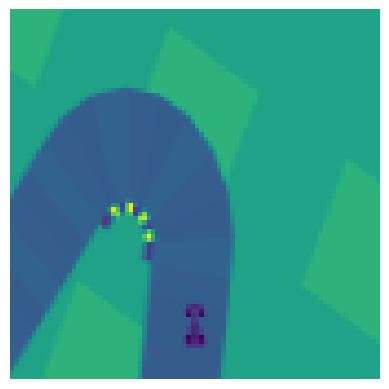

In [9]:
# Action mapping from gymnasium.farama.org
action_mapping = {
    0: "do nothing",
    1: "steer left",
    2: "steer right",
    3: "gas",
    4: "brake"
}

# Visualize random frames
idx = np.random.randint(len(dataset))
state, action = dataset[idx]
# store a single frame as we need it later for exporting an ONNX model (it needs a sample of the input for the export)
sample_state = torch.Tensor(state).unsqueeze(0).to(device)
# Display the sample
print(f"Action: {action_mapping[action]}")
plt.axis("off")
plt.imshow(state[0]);

In [10]:
# release memory
del dataset

# Define Policy Network

You need to design a neural network architecture that is capable of mapping a state to an action.
The input is a single image with the following properties:
- Resolution of 84x84 pixels
- Grayscale (meaning a single channel as opposed to three channels of an RGB image)
- The values of each pixel should be between 0 and 1

The output of the network should be one unit per possible action, as our environment has 5 actions that results in 5 output units.
Your network must implement the forward function in order to be compatible with the evaluation script.

In [11]:
class PolicyNetwork(nn.Module):
    def __init__(self, n_units_out):
        super(PolicyNetwork, self).__init__()
        ######################
        ### YOUR CODE HERE ###
        ######################


        # Input: 1 x 84 x 84 grayscale image
        # Output: logits for the 5 discrete CarRacing actions
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten(),
        )

        # Infer the flattened CNN size automatically, so we do not calculate it by hand.
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 84, 84)
            n_flatten = self.features(dummy).shape[1]

        self.classifier = nn.Sequential(
            nn.Linear(n_flatten, 512),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, n_units_out),
        )

    def forward(self, x):
        ######################
        ### YOUR CODE HERE ###
        ######################

        x = self.features(x)
        logits = self.classifier(x)
        return logits

# Train behavioral cloning policy

Now that you have a Dataset and a network you need to train your network.
With behavioral cloning we want to imitate the behavior of the agent that produced the demonstration dataset as close as possible.
This is basically supervised learning, where you want to minimize the loss of your network on the training and validation sets.

Some tips as to what you need to implement:
- choose the appropriate loss function (think on which kind of problem you are solving)
- choose an optimizer and its hyper-parameters
- optional: use a learning-rate scheduler
- don't forget to evaluate your network on the validation set
- store your model and training progress often so you don't loose progress if your program crashes

In case you use the provided Logger:
- `logger.log("training_loss", <loss-value>)` to log a particular value
- `logger.dump()` to write the current logs to a log file (e.g. after every episode)
- `logger.log_dir`, `logger.param_file`, `logger.onnx_file`, `logger.video_dir` point to files or directories you can use to save files
- you might want to specify your google drive folder as a logdir in order to automatically sync your results
- if you log the metrics specified in the `plot_metrics` function you can use it to visualize your training progress (or take it as a template to plot your own metrics)

Saving state to logdir/2026-05-18T17-51-55
Trainable Parameters: 1680549


Epoch 01/20 | train loss: 0.9312, train acc: 0.695 | val loss: 0.8803, val acc: 0.699


Epoch 02/20 | train loss: 0.8886, train acc: 0.707 | val loss: 0.8812, val acc: 0.698


Epoch 03/20 | train loss: 0.8880, train acc: 0.708 | val loss: 0.8790, val acc: 0.693


Epoch 04/20 | train loss: 0.8855, train acc: 0.708 | val loss: 0.8824, val acc: 0.702


...

Epoch 16/20 | train loss: 0.8734, train acc: 0.709 | val loss: 0.8764, val acc: 0.703


Epoch 17/20 | train loss: 0.8724, train acc: 0.710 | val loss: 0.8769, val acc: 0.700


Epoch 18/20 | train loss: 0.8729, train acc: 0.710 | val loss: 0.8773, val acc: 0.703


Epoch 19/20 | train loss: 0.8722, train acc: 0.711 | val loss: 0.8766, val acc: 0.701


Epoch 20/20 | train loss: 0.8722, train acc: 0.710 | val loss: 0.8791, val acc: 0.698


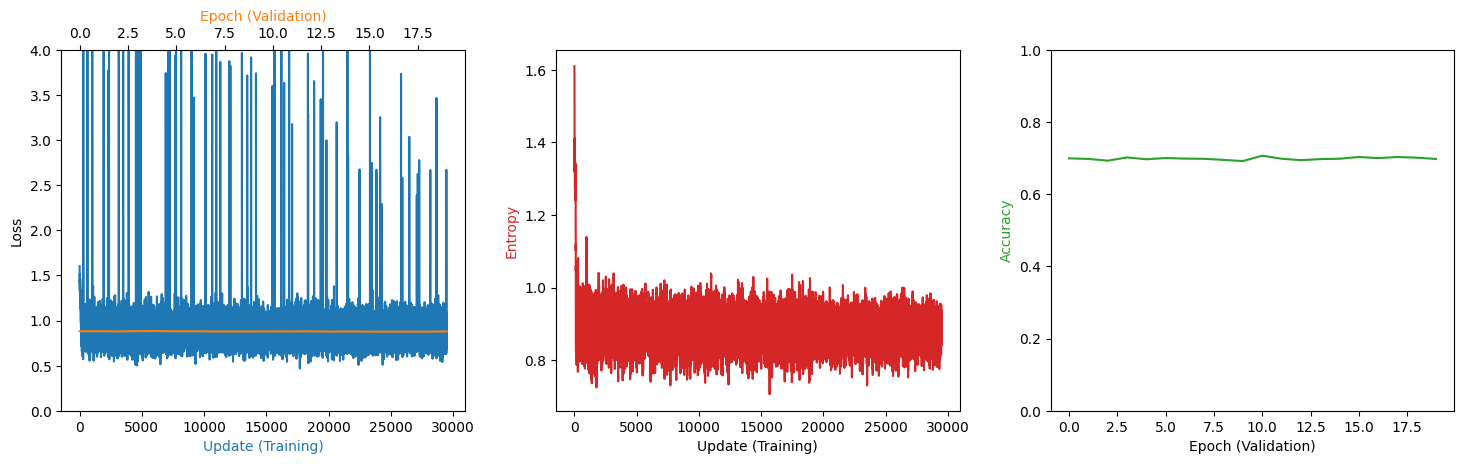

/tmp/ipykernel_10304/2044680971.py:109: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


conversion ok


In [12]:
# choose the batchsize for training
batch_size = 64

# Datasets
train_set = DemonstrationDataset("train")
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, num_workers=2, shuffle=True, drop_last=False, pin_memory=True)
val_set = DemonstrationDataset("val")
val_loader = torch.utils.data.DataLoader(val_set, batch_size=batch_size, num_workers=2, shuffle=False, drop_last=False, pin_memory=True)

# Specify the google drive mount here if you want to store logs and weights there (and set it up earlier)
# You can also choose to use a different logging framework such as tensorboard (not recommended on Colab) or Weights & Biases (highly recommended)
logger = Logger("logdir")
print("Saving state to {}".format(logger.basepath))

# Network
model = PolicyNetwork(n_units_out=5)
model = model.to(device)
num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable Parameters: {}".format(num_trainable_params))

######################
### YOUR CODE HERE ###
######################
# Implement your training and evaluation loop
# feel free to define your own functions for training and evaluation
train_actions = [np.load(path)["action"].item() for path in train_set.files]
class_counts = np.bincount(train_actions, minlength=5)
class_weights_np = np.sqrt(class_counts.sum() / np.maximum(class_counts, 1))
class_weights = torch.tensor(class_weights_np, dtype=torch.float32, device=device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=4)


def train_one_epoch(model, loader, optimizer, criterion, logger=None):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for states, actions in tqdm(loader, desc="Train", leave=False):
        states = states.to(device, non_blocking=True)
        actions = actions.to(device, non_blocking=True).long()

        brightness = (torch.rand(states.size(0), 1, 1, 1, device=device) - 0.5) * 0.06
        noise = 0.01 * torch.randn_like(states)
        states_aug = torch.clamp(states + brightness + noise, 0.0, 1.0)

        logits = model(states_aug)
        loss = criterion(logits, actions)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        with torch.no_grad():
            preds = logits.argmax(dim=1)
            entropy = Categorical(logits=logits).entropy().mean().item()
            total_correct += (preds == actions).sum().item()
            total_samples += actions.size(0)
            total_loss += loss.item() * actions.size(0)

        if logger is not None:
            logger.log("training_loss", loss.item())
            logger.log("training_entropy", entropy)

    return total_loss / total_samples, total_correct / total_samples


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for states, actions in tqdm(loader, desc="Val", leave=False):
            states = states.to(device, non_blocking=True)
            actions = actions.to(device, non_blocking=True).long()

            logits = model(states)
            loss = criterion(logits, actions)
            preds = logits.argmax(dim=1)

            total_loss += loss.item() * actions.size(0)
            total_correct += (preds == actions).sum().item()
            total_samples += actions.size(0)

    return total_loss / total_samples, total_correct / total_samples


best_val_acc = 0.0
best_val_loss = float("inf")
n_epochs = 20
early_stop_patience = 6
epochs_since_improvement = 0

for epoch in range(n_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, logger)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    scheduler.step(val_loss)

    logger.log("validation_loss", val_loss)
    logger.log("validation_accuracy", val_acc)
    logger.dump()

    print(
        f"Epoch {epoch + 1:02d}/{n_epochs} | "
        f"train loss: {train_loss:.4f}, train acc: {train_acc:.3f} | "
        f"val loss: {val_loss:.4f}, val acc: {val_acc:.3f}"
    )

    improved = False
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        improved = True
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        improved = True

    if improved:
        torch.save(model.state_dict(), os.path.join(logger.basepath, "best_bc_model.pt"))
        epochs_since_improvement = 0
    else:
        epochs_since_improvement += 1
        if epochs_since_improvement >= early_stop_patience:
            print("Early stopping: validation metrics did not improve.")
            break

# Load the best behavioral cloning model before exporting/evaluating.
model.load_state_dict(torch.load(os.path.join(logger.basepath, "best_bc_model.pt"), map_location=device))
plot_metrics(logger)



# If you want to export your model as an ONNX file use the following code as template
# If you use the provided logger you can use this directly
save_as_onnx(model, sample_state, logger.onnx_file)

# Evaluate the agent in the real environment

### Environment and Agent

We provide some wrappers you need in order to get the same states from the environment as in the demonstration dataset.
Additionally the `RecordState` wrapper should be very helpful in collecting new samples for the DAgger algorithm.

In [13]:
class CropObservation(gym.ObservationWrapper):
    def __init__(self, env, shape):
        gym.ObservationWrapper.__init__(self, env)
        self.shape = shape
        obs_shape = self.shape + env.observation_space.shape[2:]
        self.observation_space = Box(low=0, high=255, shape=obs_shape, dtype=np.uint8)

    def observation(self, observation):
        return observation[:self.shape[0], :self.shape[1]]


class RecordState(gym.Wrapper):
    def __init__(self, env: gym.Env, reset_clean: bool = True):
        gym.Wrapper.__init__(self, env)

        assert env.render_mode is not None
        self.frame_list = []
        self.reset_clean = reset_clean

    def step(self, action, **kwargs):
        output = self.env.step(action, **kwargs)
        self.frame_list.append(output[0])
        return output

    def reset(self, *args, **kwargs):
        result = self.env.reset(*args, **kwargs)

        if self.reset_clean:
            self.frame_list = []
        self.frame_list.append(result[0])

        return result

    def render(self):
        frames = self.frame_list
        self.frame_list = []
        return frames


class Agent():
    def __init__(self, model, device):
        self.model = model
        self.device = device

    def select_action(self, state):
        with torch.no_grad():
            state = torch.Tensor(state).unsqueeze(0).to(device) / 255.0 # rescale
            logits = self.model(state)
            if type(logits) is tuple:
                logits = logits[0]
            probs = Categorical(logits=logits)
            return probs.sample().cpu().numpy()[0]


def make_env(seed, capture_video=True):
    env = gym.make("CarRacing-v3", render_mode="rgb_array", continuous=False)
    env = gym.wrappers.RecordEpisodeStatistics(env)
    if capture_video:
        env = gym.wrappers.RecordVideo(env, logger.video_dir)

    env = CropObservation(env, (84, 96))
    env = gym.wrappers.ResizeObservation(env, (84, 84))
    env = gym.wrappers.GrayscaleObservation(env)
    env = RecordState(env, reset_clean=True)
    env = gym.wrappers.FrameStackObservation(env, 4)
    env.reset(seed=seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)
    return env


def run_episode(agent, show_progress=True, capture_video=True, seed=None):
    env = make_env(seed=seed, capture_video=capture_video)
    state, _ = env.reset()
    score = 0
    done = False
    if show_progress:
        progress = tqdm(desc="Score: 0")

    while not done:
        action = agent.select_action(state[-1][np.newaxis, ...])
        state, reward, terminated, truncated, _ = env.step(action)
        score += reward
        done = terminated or truncated
        if show_progress:
            progress.update()
            progress.set_description("Score: {:.2f}".format(score))
    env.close()

    if show_progress:
        progress.close()
    if capture_video:
        show_video(logger.video_dir)

    return score


## Evaluate behavioral cloning agent

Let's see how the agent is doing in the real environment

In [14]:
eval_policy = GreedyAgent(model, device) if "GreedyAgent" in globals() else Agent(model, device)
score = run_episode(eval_policy, show_progress=True, capture_video=True);
print(f"Score: {score:.2f}")

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
Score: 882.76: : 1000it [00:35, 28.27it/s]


Score: 882.76


Since we often have high variance when evaluating RL agents we should evaluate the agent multiple times to get a better feeling for its performance.

In [15]:
eval_policy = GreedyAgent(model, device) if "GreedyAgent" in globals() else Agent(model, device)
n_eval_episodes = 10
scores = []
for i in tqdm(range(n_eval_episodes), desc="Episode"):
    scores.append(run_episode(eval_policy, show_progress=False, capture_video=False))
    print("Score: %d" % scores[-1])
print("Mean Score: %.2f (Std: %.2f)" %(np.mean(scores), np.std(scores)))

Episode:  10%|█         | 1/10 [00:11<01:44, 11.58s/it]

Score: 873


Episode:  20%|██        | 2/10 [00:23<01:32, 11.58s/it]

Score: 903


Episode:  30%|███       | 3/10 [00:34<01:21, 11.65s/it]

...

Score: 892


Episode:  90%|█████████ | 9/10 [01:44<00:11, 11.46s/it]

Score: 879


Episode: 100%|██████████| 10/10 [01:55<00:00, 11.57s/it]

Score: 430
Mean Score: 725.12 (Std: 213.21)


# DAGGER

Now we can implement DAgger, you have downloaded a relatively well trained model you can use as an expert for this purpose.

Load expert model that is provided as ONNX file.

## Load the expert

In [16]:
# Load expert
expert_model = ConvertModel(onnx.load("expert.onnx"))
expert_model = expert_model.to(device)
# Freeze expert weights
for p in expert_model.parameters():
    p.requires_grad = False

expert_policy = Agent(expert_model, device)

Next, you have to implement the DAgger algorithm (see slides for details). This function implements the core idea of DAgger:


1. Choose the policy with probability beta
2. Sample T-step trajectories using this policy
3. Label the gathered states with the expert

The aggregation and training part are already implemented.

In [17]:
# inner loop of DAgger
def dagger(env, train_policy, expert_policy, dataset, beta=1., max_steps=1000):

    ######################
    ### YOUR CODE HERE ###
    ######################

    # Implement DAgger algorithm here
    # 1) Choose a policy (sample according to beta)
    # 2) Sample T-step trajectory with the chosen policy
    #    (T can be an entire episode or a single state, think about what makes more sense here and implement it accordingly)
    # 3) Label the state (or states) with your expert if they come from your training policy

    #### Note ####
    # To get an action for the current state from your training policy or expert policy:
    # action = policy.select_action(state)
    #
    # Your training policy requires a single grayscale state while
    # the expert policy requires four stacked grayscale states
    # You can prepare your state for the policy like so:
    # Train policy:
    #      np.expand_dims(state[-1], 0)
    # Expert policy:
    #      state


    # Due to the RecordState wrapper you can get the states from the environment by calling
    # env.render()
    # Doing so will clear the list and the next time you call .render() will return the new states since the last call.
    # Note: be careful with the last state

    # Finally, add collected states and the actions the expert would execute in them to the dataset
    # dataset.append(states, actions)

    state, _ = env.reset()
    done = False
    steps = 0

    collected_states = []
    expert_actions = []
    expert_actions_int = []

    while not done and steps < max_steps:
        state_np = np.asarray(state)

        expert_action = int(expert_policy.select_action(state_np))
        train_state = np.expand_dims(state_np[-1], axis=0)
        train_action = int(train_policy.select_action(train_state))

        use_expert = np.random.rand() < beta
        action = expert_action if use_expert else train_action

        if not use_expert:
            collected_states.append(state_np[-1].copy())
            expert_actions.append(np.array(expert_action, dtype=np.int32))
            expert_actions_int.append(expert_action)

        state, reward, terminated, truncated, _ = env.step(int(action))
        done = terminated or truncated
        steps += 1

    if len(collected_states) > 0:
        dataset.append(collected_states, expert_actions)

    action_hist = np.bincount(expert_actions_int, minlength=5) if len(expert_actions_int) > 0 else np.zeros(5, dtype=np.int64)
    print(f"DAgger collected {len(collected_states)} learner states with beta={beta:.2f}")
    return len(collected_states), action_hist




Put everything together now.
1. Create new samples using the DAgger algorithm
2. Continue training your agent
3. Export your fully trained agent as an ONNX file

Saving state to logdir_dagger/2026-05-18T18-11-52

DAgger iteration 1/10 | beta=0.80
DAgger collected 182 learner states with beta=0.80
DAgger collected 176 learner states with beta=0.80
DAgger collected 208 learner states with beta=0.80
Dataset size: 94284 -> 94850 (added 566)
New action histogram: [68, 83, 119, 296, 0]


  epoch 1/3 | train loss: 0.7618, train acc: 0.719 | val loss: 0.7740, val acc: 0.709


  epoch 2/3 | train loss: 0.7617, train acc: 0.720 | val loss: 0.7729, val acc: 0.710


  epoch 3/3 | train loss: 0.7611, train acc: 0.720 | val loss: 0.7733, val acc: 0.707
Mean return (5 episodes, greedy): 585.53

DAgger iteration 2/10 | beta=0.71
DAgger collected 286 learner states with beta=0.71
DAgger collected 285 learner states with beta=0.71
DAgger collected 292 learner states with beta=0.71
Dataset size: 94850 -> 95713 (added 863)
New action histogram: [92, 119, 208, 444, 0]


  epoch 1/3 | train loss: 0.7603, train acc: 0.719 | val loss: 0.7734, val acc: 0.711


...

  epoch 3/3 | train loss: 0.7476, train acc: 0.724 | val loss: 0.7729, val acc: 0.711
Mean return (5 episodes, greedy): 563.31

DAgger iteration 10/10 | beta=0.00
DAgger collected 1000 learner states with beta=0.00
DAgger collected 1000 learner states with beta=0.00
DAgger collected 1000 learner states with beta=0.00
Dataset size: 109129 -> 112129 (added 3000)
New action histogram: [369, 560, 480, 1591, 0]


  epoch 1/3 | train loss: 0.7459, train acc: 0.725 | val loss: 0.7740, val acc: 0.711


  epoch 2/3 | train loss: 0.7456, train acc: 0.726 | val loss: 0.7725, val acc: 0.711


  epoch 3/3 | train loss: 0.7458, train acc: 0.725 | val loss: 0.7745, val acc: 0.711
Mean return (5 episodes, greedy): 565.98
conversion ok


/tmp/ipykernel_10304/2044680971.py:109: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


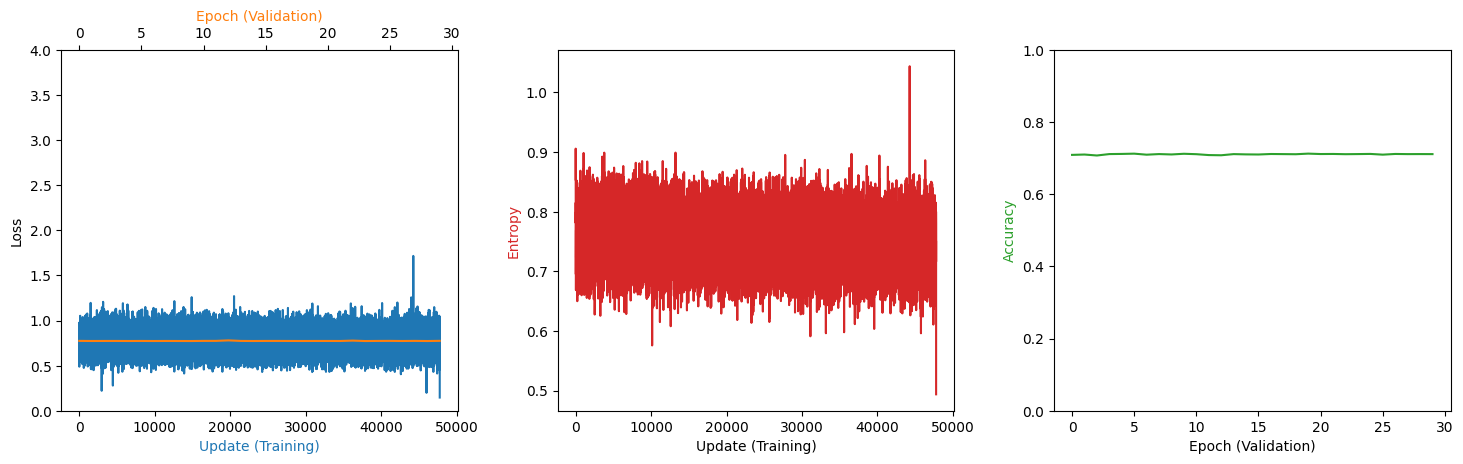

In [18]:
# Specify the google drive mount here if you want to store logs and weights there (and set it up earlier)
logger = Logger("logdir_dagger")
print("Saving state to {}".format(logger.basepath))

# start environment
env = make_env(seed=42, capture_video=False)

# Training
######################
### YOUR CODE HERE ###
######################

train_policy = Agent(model, device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5, weight_decay=1e-5)

n_dagger_iterations = 10
epochs_per_iteration = 3
rollouts_per_iteration = 3
beta_schedule = np.linspace(0.8, 0.0, n_dagger_iterations)
best_mean_return = -float("inf")


class GreedyAgent(Agent):
    def select_action(self, state):
        with torch.no_grad():
            state = torch.Tensor(state).unsqueeze(0).to(device) / 255.0
            logits = self.model(state)
            if type(logits) is tuple:
                logits = logits[0]
            return int(torch.argmax(logits, dim=1).item())


def evaluate_policy_mean_return(policy, n_episodes=5):
    returns = []
    for _ in range(n_episodes):
        returns.append(run_episode(policy, show_progress=False, capture_video=False))
    return float(np.mean(returns))


for iteration, beta in enumerate(beta_schedule):
    print(f"\nDAgger iteration {iteration + 1}/{n_dagger_iterations} | beta={beta:.2f}")
    size_before = len(train_set)

    iter_added = 0
    iter_hist = np.zeros(5, dtype=np.int64)
    for _ in range(rollouts_per_iteration):
        n_added, action_hist = dagger(env, train_policy, expert_policy, train_set, beta=float(beta), max_steps=1000)
        iter_added += n_added
        iter_hist += action_hist

    size_after = len(train_set)
    print(f"Dataset size: {size_before} -> {size_after} (added {iter_added})")
    print(f"New action histogram: {iter_hist.tolist()}")

    # 2) Rebuild the loader because train_set now contains more files.
    train_loader = torch.utils.data.DataLoader(
        train_set,
        batch_size=batch_size,
        num_workers=2,
        shuffle=True,
        drop_last=False,
        pin_memory=True,
    )

    # 3) Continue supervised training on the aggregated dataset.
    for epoch in range(epochs_per_iteration):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, logger)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        logger.log("validation_loss", val_loss)
        logger.log("validation_accuracy", val_acc)
        logger.dump()

        print(
            f"  epoch {epoch + 1}/{epochs_per_iteration} | "
            f"train loss: {train_loss:.4f}, train acc: {train_acc:.3f} | "
            f"val loss: {val_loss:.4f}, val acc: {val_acc:.3f}"
        )

    greedy_policy = GreedyAgent(model, device)
    mean_return = evaluate_policy_mean_return(greedy_policy, n_episodes=5)
    print(f"Mean return (5 episodes, greedy): {mean_return:.2f}")

    torch.save(model.state_dict(), os.path.join(logger.basepath, f"dagger_iter_{iteration + 1}.pt"))
    if mean_return > best_mean_return:
        best_mean_return = mean_return
        torch.save(model.state_dict(), os.path.join(logger.basepath, "best_dagger_model.pt"))

best_dagger_path = os.path.join(logger.basepath, "best_dagger_model.pt")
if os.path.exists(best_dagger_path):
    model.load_state_dict(torch.load(best_dagger_path, map_location=device))

# Export final DAgger model.
save_as_onnx(model, sample_state, logger.onnx_file)
plot_metrics(logger)

env.close()



In [19]:
n_eval_episodes = 10
scores = []
for i in tqdm(range(n_eval_episodes), desc="Episode"):
    scores.append(run_episode(train_policy, show_progress=False, capture_video=False))
    print("Score: %d" % scores[-1])
print("Mean Score: %.2f (Std: %.2f)" %(np.mean(scores), np.std(scores)))

Episode:  10%|█         | 1/10 [00:11<01:43, 11.51s/it]

Score: 607


Episode:  20%|██        | 2/10 [00:22<01:31, 11.45s/it]

Score: 445


Episode:  30%|███       | 3/10 [00:35<01:22, 11.80s/it]

...

Score: 650


Episode:  90%|█████████ | 9/10 [01:47<00:12, 12.14s/it]

Score: 708


Episode: 100%|██████████| 10/10 [01:59<00:00, 12.00s/it]

Score: 408
Mean Score: 576.35 (Std: 177.53)
